# Keras 활용 온라인 채널 제품 판매량 예측

본 노트북에서는 주어진 데이터를 바탕으로 제품별 일일 판매량을 예측하는 모델을 구성합니다.
Keras 기반의 딥러닝 모델(DNN)을 사용하여 파이프라인(데이터 준비, EDA, 전처리, 특성 공학, 모델링, 평가, 예측)을 순차적으로 수행합니다.

## 1. 컬럼별 설명 및 데이터셋 소개
- **`train.csv`**: 모델 학습을 위한 핵심 데이터로, 상품의 일자별 판매량 등이 포함되어 있습니다.
  - 통상적으로 `제품 식별자(ID)`와 날짜(예: `2022-01-01` ~ `2023-04-04`) 형태의 컬럼으로 시계열 값(판매량)이 들어있습니다.
- **`sales.csv`**: 상세한 일별 총 판매금액, 판매 수량 등의 세부 거래 로그 데이터가 들어있을 수 있습니다.
- **`product_info.csv`**: 제품 메타 정보. 카테고리(대분류, 소분류 등), 특성 등의 내용을 담고 있어 특성 공학에 용이합니다.
- **`brand_keyword_cnt.csv`**: 특정 브랜드에 대한 일자별 키워드 검색량 데이터입니다. 외부 특성으로 사용할 수 있습니다.
- **`sample_submission.csv`**: 최종 예측을 기록하여 제출할 양식 파일입니다.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

## 2. 데이터 불러오기

In [2]:
data_dir = './data'

# CSV 파일 로드
train = pd.read_csv(os.path.join(data_dir, 'train.csv'))
sales = pd.read_csv(os.path.join(data_dir, 'sales.csv'))
product_info = pd.read_csv(os.path.join(data_dir, 'product_info.csv'))
sample_submission = pd.read_csv(os.path.join(data_dir, 'sample_submission.csv'))

display(train.head())

,ID,제품,대분류,중분류,소분류,브랜드,2022-01-01,2022-01-02,2022-01-03,2022-01-04,...,2023-03-26,2023-03-27,2023-03-28,2023-03-29,2023-03-30,2023-03-31,2023-04-01,2023-04-02,2023-04-03,2023-04-04
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,1,3,2,0,0,2,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. 탐색적 데이터 분석 (EDA) 및 시각화

데이터의 상태를 점검하고, 판매 데이터가 어떤 식의 패턴을 띠는지 살펴봅니다.

In [3]:
print("Train Data Shape:", train.shape)
print("Train Data Info:")
train.info()

# 제품별 결측치 존재 여부 간략 확인 (데이터가 많은 경우 전체 요약치)
print("\n결측치 총합 요약:")
print(train.isnull().sum().sort_values(ascending=False).head(5))

Train Data Shape: (15890, 465)
Train Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 15890 entries, 0 to 15889
Columns: 465 entries, ID to 2023-04-04
dtypes: int64(460), str(5)
memory usage: 56.4 MB

결측치 총합 요약:
ID     0
제품     0
대분류    0
중분류    0
소분류    0
dtype: int64


시계열 형태로 되어있는 `train.csv`를 행(Row) 단위로 처리하기 위해 `melt` 함수를 이용해 **일렬 데이터(Long form)**로 변환해줍니다.

In [4]:
# 컬럼명 중 날짜 형식(예: YYYY-MM-DD 가로형)을 가진 열들만 추출합니다.
date_columns = [col for col in train.columns if '2022-' in col or '2023-' in col]
item_columns = [col for col in train.columns if col not in date_columns]

# Melt
if date_columns:
    train_melt = pd.melt(train, id_vars=item_columns, value_vars=date_columns, var_name='date', value_name='sales')
else:
    train_melt = train.copy() # 만약 가로형 데이터가 아니라면 그대로 유지

display(train_melt.head())

,ID,제품,대분류,중분류,소분류,브랜드,date,sales
0,0,B002-00001-00001,B002-C001-0002,B002-C002-0007,B002-C003-0038,B002-00001,2022-01-01,0
1,1,B002-00002-00001,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,2022-01-01,0
2,2,B002-00002-00002,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,2022-01-01,0
3,3,B002-00002-00003,B002-C001-0003,B002-C002-0008,B002-C003-0044,B002-00002,2022-01-01,0
4,4,B002-00003-00001,B002-C001-0001,B002-C002-0001,B002-C003-0003,B002-00003,2022-01-01,0


### 전체 일간 누적 판매량 시각화 추이

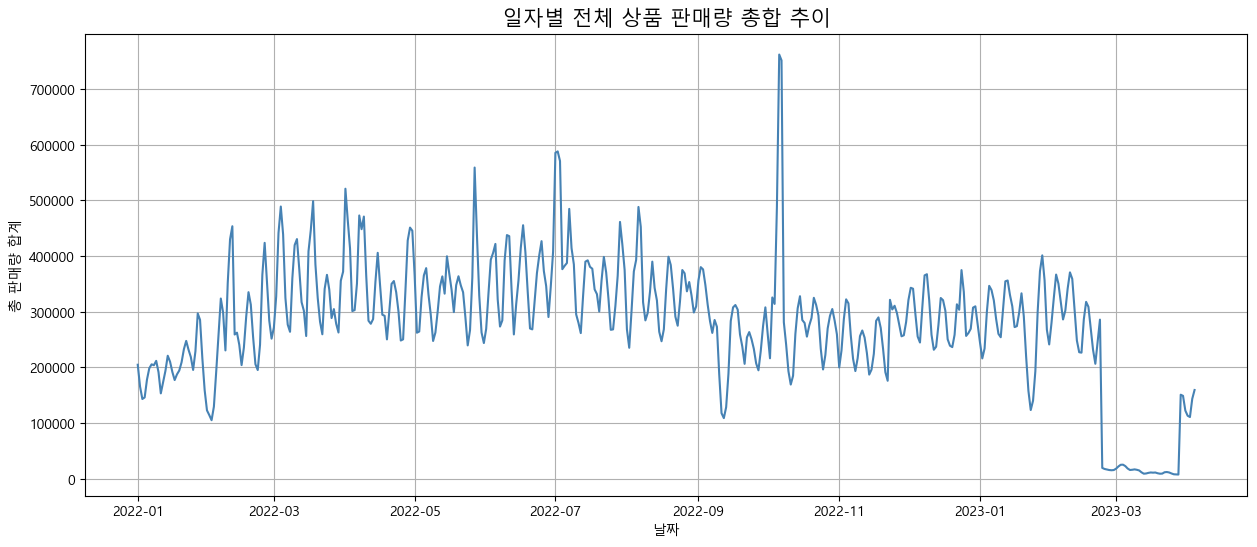

In [5]:
if 'date' in train_melt.columns and 'sales' in train_melt.columns:
    train_melt['date'] = pd.to_datetime(train_melt['date'])
    
    daily_sales = train_melt.groupby('date')['sales'].sum().reset_index()
    daily_sales = daily_sales.sort_values('date')
    
    plt.figure(figsize=(15, 6))
    plt.plot(daily_sales['date'], daily_sales['sales'], color='steelblue')
    plt.title('일자별 전체 상품 판매량 총합 추이', fontsize=15)
    plt.xlabel('날짜')
    plt.ylabel('총 판매량 합계')
    plt.grid(True)
    plt.show()

## 4. 데이터 전처리 (Preprocessing)

- 결측치(NaN) 제거 및 보간 (판매량이 빈 부분은 0으로 대체할 수 있습니다.)
- 데이터 메타 정보를 활용해 `product_info` 데이터프레임을 추가로 병합합니다.

In [ ]:
# 결측치는 보통 0으로 처리하거나 앞/뒤의 값을 채우는 방법이 있습니다.
train_melt['sales'].fillna(0, inplace=True)

# 제품 메타 데이터 결합 (예: 'ID' 또는 '제품명' 등의 기준 사용)
# 여기서는 ID 컬럼이 있다고 가정, 데이터에 따라 'ID' 혹은 '제품' 컬럼명을 매칭해주어야 합니다.
merge_key = 'ID' if 'ID' in train_melt.columns else ('product_id' if 'product_id' in train_melt.columns else None)

if merge_key and merge_key in product_info.columns:
    train_melt = pd.merge(train_melt, product_info, on=merge_key, how='left')
    print(f"product_info 테이블이 '{merge_key}' 기준으로 병합되었습니다.")

## 5. 특성 공학 (Feature Engineering)

시계열 예측에서 중요한 날짜 관련 파생 변수(월, 일, 요일) 생성 및 범주형 데이터 인코딩, 수치형 데이터 스케일링을 실시합니다.

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

if 'date' in train_melt.columns:
    train_melt['year'] = train_melt['date'].dt.year
    train_melt['month'] = train_melt['date'].dt.month
    train_melt['day'] = train_melt['date'].dt.day
    train_melt['dayofweek'] = train_melt['date'].dt.dayofweek

# 카테고리(범주형) 변수 Label Encoding
categorical_cols = train_melt.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col not in ['date']] # date 컬럼 제외

for col in categorical_cols:
    train_melt[col] = train_melt[col].astype(str)
    le = LabelEncoder()
    train_melt[col] = le.fit_transform(train_melt[col])

# 수치형 변수 Min-Max 스케일링 준비 (타겟 변수인 sales와 date 정보 등을 제외한 나머지만 변환)
exclude_cols = ['sales', 'date', 'ID', 'product_id']
features = [col for col in train_melt.columns if col not in exclude_cols]

scaler = MinMaxScaler()
if len(features) > 0:
    train_melt[features] = scaler.fit_transform(train_melt[features])

display(train_melt[features].head())

## 6. 모델링: Keras를 활용한 딥러닝 모델 개발

데이터를 학습/검증용(Train/Validation)으로 나눈 뒤, 다층 퍼셉트론(MLP/DNN) 모델을 구성합니다.
※ 시계열 데이터인 만큼 LSTM, GRU와 같은 Sequence 모델 또한 유용하지만 기초적인 Baseline 관점에서 Dense Layer로 접근합니다.

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 재현성을 위한 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

target = 'sales'
X = train_melt[features].values
y = train_melt[target].values

# 데이터 분리 (학습 : 검증 = 8:2)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set :", X_train.shape, y_train.shape)
print("Validation Set :", X_val.shape, y_val.shape)

In [ ]:
# 간단한 Dense Network (DNN) 정의
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='relu') # 판매량은 0 이상이므로 ReLU 통과 혹은 linear를 사용
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

### 학습 진행

In [ ]:
# 과적합 방지를 위한 조기종료(Early Stopping) 셋팅
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 학습
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

## 7. 모델 평가 (Model Evaluation)

학습된 모델의 학습 곡선(Learning Curve)을 확인하고, 오차 지표(MSE, MAE)를 진단합니다.

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title('훈련 및 검증 학습 오차 (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('훈련 및 검증 학습 오차 (MAE)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# 검증 데이터 셋 성능 수치 표기
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
print(f"최종 검증 Loss (MSE): {val_loss:.4f}")
print(f"최종 검증 MAE: {val_mae:.4f}")

## 8. 향후 예측 (Predict)

실제 평가용 데이터(추론 일자 구간)가 주어진다고 가정할 때, 이를 바탕으로 모델의 `predict` 함수를 사용합니다.
결과값은 제출 양식인 `sample_submission.csv` 에 매핑하여 CSV 형태로 저장합니다.

In [ ]:
# [참고용 가이드]
# 추론 기간에 해당하는 특성 데이터(Test set)를 앞선 train의 특성 공학 파이프라인과 동일하게 구축한 뒤,
# 예측된 값들을 sample_submission 결과 양식에 반영해 파일로 반환합니다.

"""
# 예시 코드
# test_features = make_test_features() # 학습때와 동일한 특성의 X_test 행렬을 만듦
# test_features_scaled = scaler.transform(test_features)

# predictions = model.predict(test_features_scaled)

# sample_submission['sales'] = predictions.flatten()
# sample_submission.to_csv('./data/my_submission.csv', index=False)
"""

display(sample_submission.head())